In [ ]:
import numpy as np
import torch
import gymnasium as gym
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from torch.utils import tensorboard

#CartPole Environment

The CartPole environment is a classic learning environment, introduced by Barto, Sutton, and Anderson in “Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem” from 1983. It consists of a pole attached to a cart, which moves friction-free along a line. The objective is to balance the pole by moving the cart.

The action space is discrete, with two possible actions 0 or 1, respectively push left and right.

The observation space is continuous and 4-dimensional:

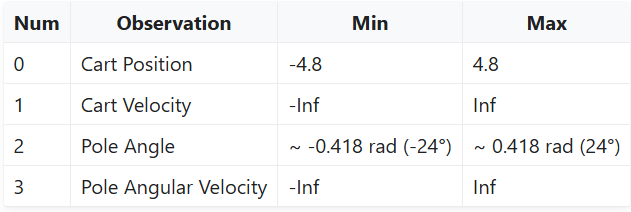

The episode has strict termination limits, when the Cart Position exits the $[-2.4; 2.4]$ interval or the Pole Angle exits the $[-12°; 12°]$ interval.

We want the pole upright for as long as possible, therefore each step in the accepted ranges gives the agent a +1 reward. The episode terminates when either the position or angle accepted ranges are exceeded or when the agent reaches a total reward of 500, which is considered a success.

The starting state for each episode is defined by sampling the four observation variables from a uniform distribution in the $(-0.05; 0.05)$ range.

In [ ]:
env = gym.make("CartPole-v1")

In [ ]:
print(env.action_space)
print(env.observation_space)

Discrete(2)
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


#Introduction to Proximal Policy Optimization (T2)

The Proximal Policy Optimization algorithm is an On-policy algorithm which tries to reduce variance and increase training efficiency by sampling from previous trajectories through the use of Importance Sampling.

Importance Sampling allows to transform expected values over one distribution, say $p(x)$, into expected value over another, say $q(x)$, by appropriately weighting the values. The name of the technique comes from it's use in the context of Monte Carlo sampling, where the most important samples for a given distribution may be obtained by focusing on a specific sub-sector of the sample space.

$$E_{p}[f(x)] = \int f(x)p(x)dx = \int f(x) \frac{p(x)}{q(x)}q(x)dx = E_q[f(x)\frac{p(x)}{q(x)}]$$

The quantity $\frac{p(x)}{q(x)}$ is known as the importance sampling weight. The main difficulty in using IS in the context of On-policy algorithms comes from the likely increase in variance:

$$var(\hat{\mu}_q) = \frac{1}{n}(E_p[\frac{p(x)}{q(x)}(f(x))^2] - (E_p[f(x)])^2)$$

If the importance sampling weight is large, that is if the difference between the two distributions is large, then the variance is large as well and the resulting inferences aren't reliable.

To use Importance Sampling in the context of RL we need a way to limit the difference between the previous and the new policy. in PPO-Clip, which is the version we use here, this is done by clipping the ratio between the old and new policy so as to never exceed a certain $\epsilon$ threshold. This simple mechanism allows the use of IS in a computationally efficient manner with respect, for example, to second order methods like TRPO (Trust Region Policy Optimization).

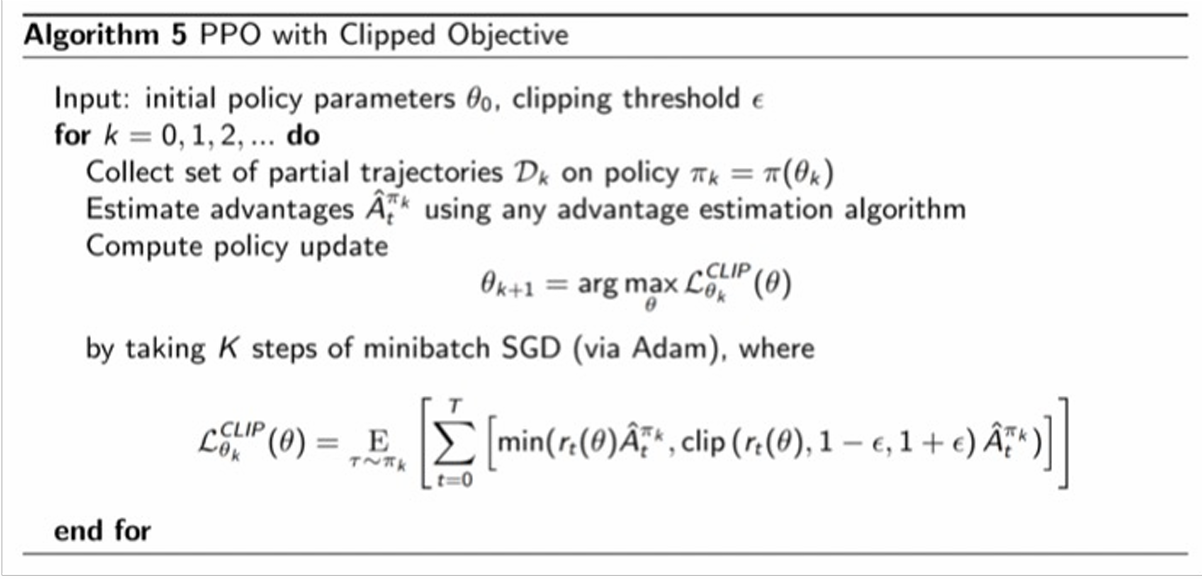

#Actor and Critic Networks (T1, T2)

We estimate the advantage throught two distinct Actor and Critic networks. The actor objective is to suggest the best action for the given state. To do this it uses two linear hidden layers and a softmax output layer, which gives us a probability distribution over the action space.

The critic objective instead is to estimate a value function which is used to judge the action the actor has selected. It uses the same architecture of the Actor, but the output is a single scalar value.

If the action gives a higher reward then the critic estimated, the advantage is positive and that action probability is strenghtened. Viceversa, the advantage is negative and the probability lowered.

In [ ]:
# Actor module, categorical actions only
class Actor(nn.Module):
    def __init__(self, state_dim, n_actions, activation=nn.ReLU):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            activation(),
            nn.Linear(64, 32),
            activation(),
            nn.Linear(32, n_actions),
            nn.Softmax(dim=-1)
        )

    def forward(self, X):
        return self.model(X)

In [ ]:
# Critic module
class Critic(nn.Module):
    def __init__(self, state_dim, activation=nn.ReLU):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            activation(),
            nn.Linear(64, 32),
            activation(),
            nn.Linear(32, 1)
        )

    def forward(self, X):
        return self.model(X)

#Network initialization and utility functions (T1)

The main hyperparameters we have selected are the discount factor, used in the definition of the Advantage, and the epsilon for the clipping. We also have the learning rates of the Actor and Critic networks and the training specific parameters, witht the number of episodes to train for and the batch size to use for each optimization.

In [ ]:
#Hyperparameters
gamma = 0.98
eps = 0.2
delta = 0.01 #Entropy Multiplier

actor_lr = 3e-4
critic_lr = 1e-3

num_episodes = 1000
batch_size = 10


In [ ]:
#Initialization
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
actor = Actor(state_dim, n_actions)
critic = Critic(state_dim)
adam_actor = torch.optim.Adam(actor.parameters(), lr=actor_lr)
adam_critic = torch.optim.Adam(critic.parameters(), lr=critic_lr)

torch.manual_seed(1)

In [ ]:
def clip_grad_norm_(module):
    nn.utils.clip_grad_norm_([p for g in module.param_groups for p in g["params"]], 0.5)

def policy_loss(old_log_prob, log_prob, advantage, eps):
    ratio = (log_prob - old_log_prob).exp()
    clipped = torch.clamp(ratio, 1-eps, 1+eps)*advantage

    m = torch.min(ratio*advantage, clipped)
    return -m

In [ ]:
def compute_advantages(rewards, values, next_value, dones, gamma=0.99, tau=0.95):
    advantages = torch.zeros_like(rewards)
    last_gae_lam = 0
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_non_terminal = 1.0 - dones[-1]
            next_values = next_value
        else:
            next_non_terminal = 1.0 - dones[t+1]
            next_values = values[t+1]

        delta = rewards[t] + gamma * next_values * next_non_terminal - values[t]
        advantages[t] = last_gae_lam = delta + gamma * tau * next_non_terminal * last_gae_lam

    returns = advantages + values
    return advantages, returns

In [ ]:
#Training

In [ ]:
episode_rewards = []

for i in range(num_episodes):
    states, actions, rewards, log_probs, values, masks = [], [], [], [], [], []
    state, _ = env.reset()
    done = False
    total_reward = 0

    #Data Collection
    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        probs = actor(state_tensor)
        value = critic(state_tensor)

        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state_tensor)
        actions.append(action)
        rewards.append(torch.FloatTensor([reward]))
        log_probs.append(dist.log_prob(action))
        values.append(value)
        masks.append(torch.FloatTensor([1 - done]))

        state = next_state
        total_reward += reward

    #Advantage calculations is vectorized using PyTorch
    states = torch.cat(states)
    actions = torch.cat(actions)
    rewards = torch.cat(rewards)
    log_probs = torch.cat(log_probs).detach()
    values = torch.cat(values).detach()

    next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
    next_value = critic(next_state_tensor).detach()

    advantages, returns = compute_advantages(rewards.squeeze(), values.squeeze(), next_value, 1-torch.cat(masks))
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8) #Normalization for stability

    for _ in range(batch_size):
        new_probs = actor(states)
        dist = torch.distributions.Categorical(new_probs)
        new_log_probs = dist.log_prob(actions)
        entropy = dist.entropy().mean() #We add the entropi to the loss for a better exploration

        loss_pi = policy_loss(log_probs, new_log_probs, advantages, eps).mean() #Clipped loss

        new_values = critic(states).view(-1)
        returns_1d = returns.view(-1)
        loss_v = F.mse_loss(new_values, returns_1d) #MSE for the Critic Loss

        #Total Loss
        total_loss = loss_pi + 0.5*loss_v - delta*entropy

        adam_actor.zero_grad()
        adam_critic.zero_grad()
        total_loss.backward()

        nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
        nn.utils.clip_grad_norm_(critic.parameters(), 0.5)

        adam_actor.step()
        adam_critic.step()

    episode_rewards.append(total_reward)
    if i%50 == 0:
      print(f"Episode {i}: Last Reward = {total_reward}, Average Reward {np.mean(episode_rewards)}")

Episode 0: Last Reward = 31.0, Average Reward 31.0
Episode 50: Last Reward = 61.0, Average Reward 22.50980392156863
Episode 100: Last Reward = 133.0, Average Reward 64.63366336633663
Episode 150: Last Reward = 438.0, Average Reward 154.08609271523179
Episode 200: Last Reward = 500.0, Average Reward 236.0099502487562
Episode 250: Last Reward = 500.0, Average Reward 282.75298804780874
Episode 300: Last Reward = 500.0, Average Reward 316.7109634551495
Episode 350: Last Reward = 500.0, Average Reward 341.5071225071225
Episode 400: Last Reward = 500.0, Average Reward 360.0074812967581
Episode 450: Last Reward = 500.0, Average Reward 374.8758314855876
Episode 500: Last Reward = 500.0, Average Reward 386.67265469061874
Episode 550: Last Reward = 500.0, Average Reward 396.95644283121595
Episode 600: Last Reward = 500.0, Average Reward 405.4692179700499
Episode 650: Last Reward = 500.0, Average Reward 412.06912442396316
Episode 700: Last Reward = 500.0, Average Reward 418.0085592011412
Episode 

#Model performance (T3)

The model performances show that even a relatively simple implementation of PPO can manage a small continous observation space paired with a small discrete action space without a problem. A total reward of 500 signals a successful episode and the network is able to achieve that most of the episodes, by the end of training. A few episodes still show a drop in reward, but they are few and apart and could correspond to particularly difficult initial conditions.

Different Actor learning rates (1e-4, 3e-4, 1e-3), different entropy multipliers (0.001, 0.01) didn't really show much of a difference in performances. Increasing the number of episodes from 500 to 1000 showed improved stability.

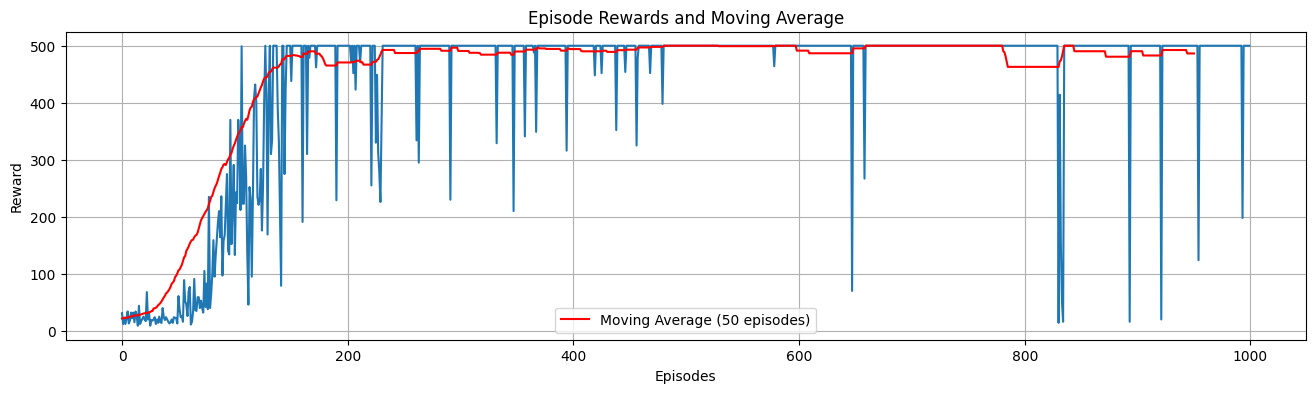

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(episode_rewards)

#Moving average
window_size = 50
if len(episode_rewards) >= window_size:
    moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg, color='red', label=f'Moving Average ({window_size} episodes)')
    plt.legend()

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Episode Rewards and Moving Average")
plt.grid(True)
plt.show()